In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import scipy 
import pandas as pd
import h5py
from pathlib import Path


print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Pandas:", pd.__version__)
print("h5py:", h5py.__version__)

NumPy: 2.4.6
SciPy: 1.17.1
Pandas: 3.0.3
h5py: 3.16.0


In [2]:
def get_thinfilm_file_path(parent_dir, Ca, Re, theta):
    parent_dir = Path(parent_dir)

    folder_name = (
        f"Ca_{Ca:07.4f}_"
        f"Re_{Re:07.3f}_"
        f"theta_{theta:06.3f}"
    )

    file_path = parent_dir / folder_name / "thinfilm_training_data.h5"

    if not file_path.exists():
        raise FileNotFoundError(
            f"HDF5 file not found:\n{file_path}"
        )

    return file_path

In [3]:
#Parent directory for white noise data
parent_dir = r"/blue/bala1s/krishnap.kalivel/TLFHydrodynamics/thinfilm-closure-ml/datasets/ROM_Ca_Re_sweep"

#Parent directory for constant frequency data
# parent_dir = r"/blue/bala1s/krishnap.kalivel/TLFHydrodynamics/thinfilm-closure-ml/datasets/frequency_Ca_Re_theta_sweep"

In [4]:
Ca_values = [0.001, 0.01, 0.1]
Re_values = [5, 20, 40, 60, 80]
# theta = 6.4
# f = 3.0

theta = 45

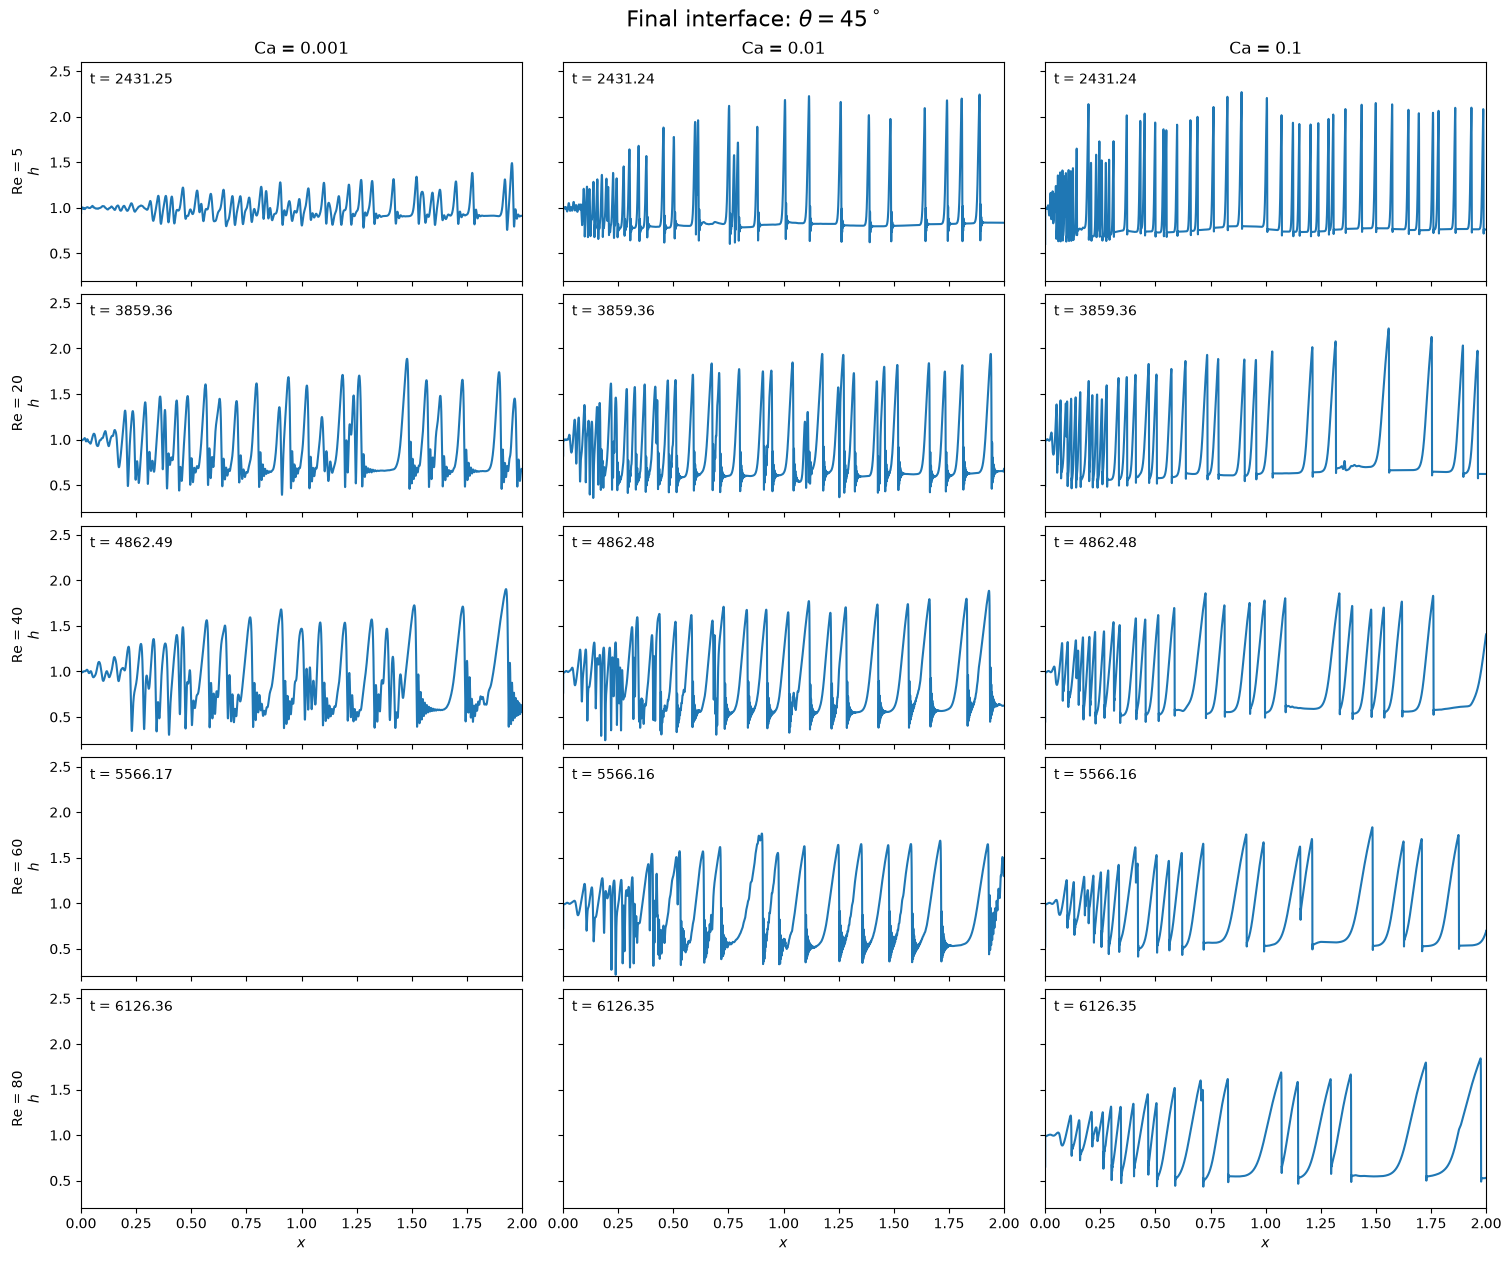

In [5]:
nrows = len(Re_values)
ncols = len(Ca_values)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5 * ncols, 2.5 * nrows),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

# Make axes always 2D
axes = np.atleast_2d(axes)

for i, Re in enumerate(Re_values):
    for j, Ca in enumerate(Ca_values):

        ax = axes[i, j]

        try:
            file_path = get_thinfilm_file_path(
                parent_dir,
                Ca=Ca,
                Re=Re,
                theta=theta,
            )
            

            with h5py.File(file_path, "r") as file:
                x = file["x"][:].squeeze()
                time = file["time"][:].squeeze()
                h_final = file["h"][:, -1]
                hN = file.attrs["hN"][0]

            ax.plot(x*hN, h_final)

            # Show final time inside panel
            ax.text(
                0.02,
                0.95,
                f"t = {time[-1]:.2f}",
                transform=ax.transAxes,
                va="top"
            )

        except FileNotFoundError:
            ax.text(
                0.5,
                0.5,
                "File not found",
                transform=ax.transAxes,
                ha="center",
                va="center"
            )

        # Column titles = Ca
        if i == 0:
            ax.set_title(f"Ca = {Ca:g}")

        # Row labels = Re
        if j == 0:
            ax.set_ylabel(f"Re = {Re}\n$h$")

        # x labels only on bottom row
        if i == nrows - 1:
            ax.set_xlabel("$x$")
            
        ax.set_xlim(0.0, 2.0)
        ax.set_ylim(0.2, 2.6)


fig.suptitle(
    rf"Final interface: $\theta={theta}^\circ$",
    fontsize=16
)

plt.show()

Plot data histograms

In [6]:
Ca = 0.01
Re = 20
theta = 45

file_path = get_thinfilm_file_path(
    parent_dir,
    Ca=Ca,
    Re=Re,
    theta=theta,
)
            

with h5py.File(file_path, "r") as file:
    x = file["x"][:].squeeze()
    time = file["time"][:].squeeze()
    h   = file["h"][:]
    h_x = file["h_x"][:]
    h_xx = file["h_xx"][:]
    q   = file["q"][:]
    q_x = file["q_x"][:]
    q_xx = file["q_xx"][:]

    hN = float(file.attrs["hN"][0])

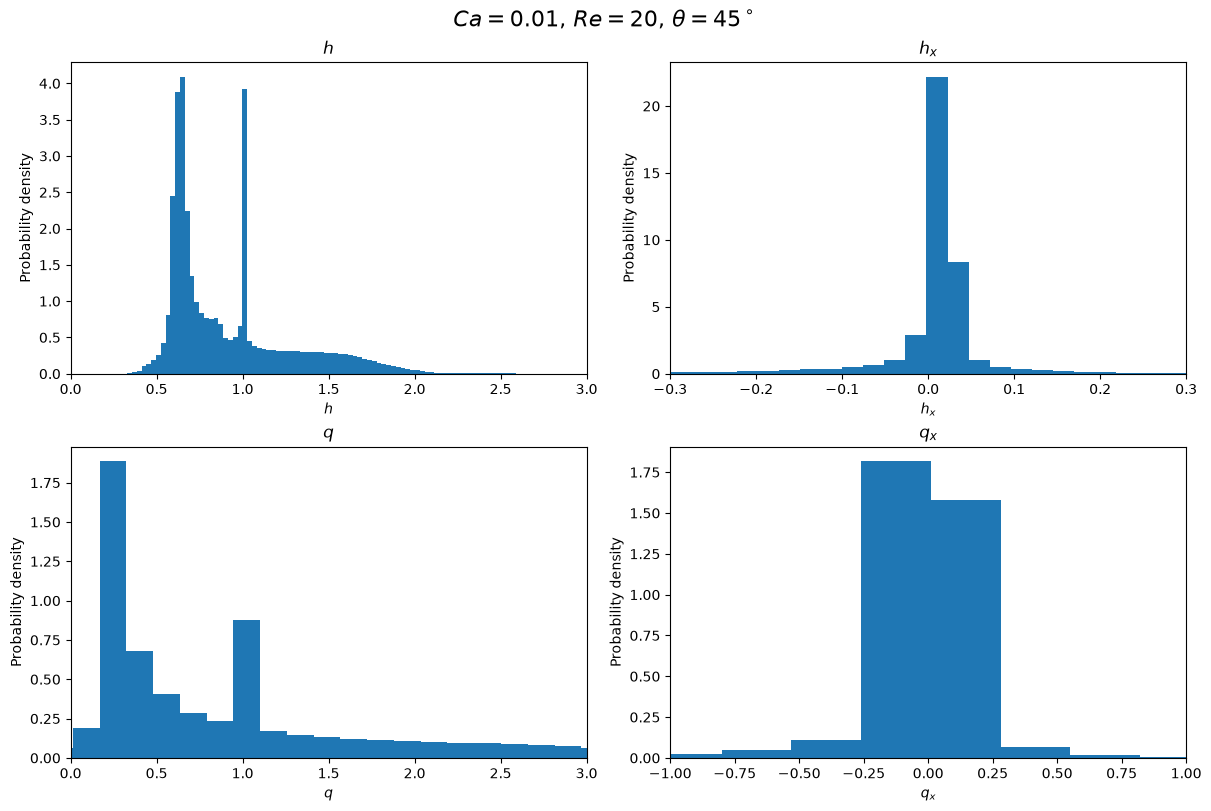

In [7]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    constrained_layout=True
)

# h
axes[0, 0].hist(
    h.ravel(),
    bins=100,
    density=True
)
axes[0, 0].set_xlabel(r"$h$")
axes[0, 0].set_ylabel("Probability density")
axes[0, 0].set_title(r"$h$")
axes[0,0].set_xlim(0, 3.0)

# h_x
axes[0, 1].hist(
    h_x.ravel(),
    bins=100,
    density=True
)
axes[0, 1].set_xlabel(r"$h_x$")
axes[0, 1].set_ylabel("Probability density")
axes[0, 1].set_title(r"$h_x$")
axes[0,1].set_xlim(-0.3, 0.3)

# q
axes[1, 0].hist(
    q.ravel(),
    bins=100,
    density=True
)
axes[1, 0].set_xlabel(r"$q$")
axes[1, 0].set_ylabel("Probability density")
axes[1, 0].set_title(r"$q$")
axes[1,0].set_xlim(0, 3.0)

# q_x
axes[1, 1].hist(
    q_x.ravel(),
    bins=100,
    density=True
)
axes[1, 1].set_xlabel(r"$q_x$")
axes[1, 1].set_ylabel("Probability density")
axes[1, 1].set_title(r"$q_x$")

fig.suptitle(
    rf"$Ca={Ca}$, $Re={Re}$, $\theta={theta}^\circ$",
    fontsize=16
)
axes[1,1].set_xlim(-1.0, 1.0)


plt.show()

In [8]:
tol = 1e-8

# A point is undisturbed only if BOTH h and q are approximately 1
undisturbed = (
    np.isclose(h, 1.0, atol=tol, rtol=0.0)
    & np.isclose(q, 1.0, atol=tol, rtol=0.0)
)

# Therefore a point is disturbed if either h or q differs from 1
disturbed = ~undisturbed

keep_mask = np.maximum.accumulate(
    disturbed[::-1, :],
    axis=0
)[::-1, :]

h_filtered   = h[keep_mask]
hx_filtered  = h_x[keep_mask]
hxx_filtered  = h_xx[keep_mask]
q_filtered   = q[keep_mask]
qx_filtered  = q_x[keep_mask]
qxx_filtered  = q_xx[keep_mask]

total_points = keep_mask.size
kept_points = np.count_nonzero(keep_mask)
discarded_points = total_points - kept_points

print(f"Total data points:     {total_points:,}")
print(f"Kept data points:      {kept_points:,}")
print(f"Discarded data points: {discarded_points:,}")
print(f"Discarded fraction:    {discarded_points / total_points:.2%}")

Total data points:     12,000,000
Kept data points:      10,992,173
Discarded data points: 1,007,827
Discarded fraction:    8.40%


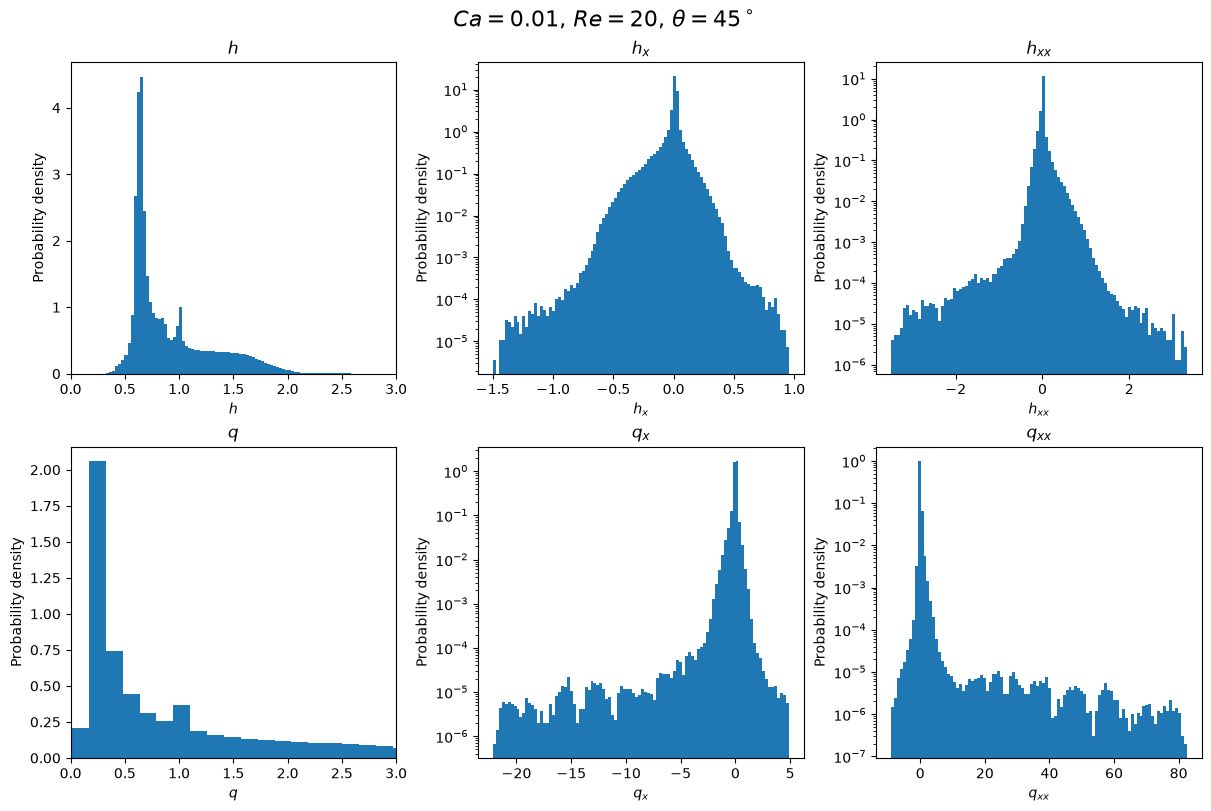

In [9]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(12, 8),
    constrained_layout=True
)

# h
axes[0, 0].hist(
    h_filtered.ravel(),
    bins=100,
    density=True
)
axes[0, 0].set_xlabel(r"$h$")
axes[0, 0].set_ylabel("Probability density")
axes[0, 0].set_title(r"$h$")
axes[0,0].set_xlim(0, 3.0)

# h_x
axes[0, 1].hist(
    hx_filtered.ravel(),
    bins=100,
    density=True
)
axes[0, 1].set_xlabel(r"$h_x$")
axes[0, 1].set_ylabel("Probability density")
axes[0, 1].set_title(r"$h_x$")
axes[0, 1].set_yscale("log")
# axes[0,1].set_xlim(-0.3, 0.3)

# h_xx
axes[0, 2].hist(
    hxx_filtered.ravel(),
    bins=100,
    density=True
)
axes[0, 2].set_xlabel(r"$h_{xx}$")
axes[0, 2].set_ylabel("Probability density")
axes[0, 2].set_title(r"$h_{xx}$")
axes[0, 2].set_yscale("log")

# q
axes[1, 0].hist(
    q_filtered.ravel(),
    bins=100,
    density=True
)
axes[1, 0].set_xlabel(r"$q$")
axes[1, 0].set_ylabel("Probability density")
axes[1, 0].set_title(r"$q$")
axes[1,0].set_xlim(0, 3.0)

# q_x
axes[1, 1].hist(
    qx_filtered.ravel(),
    bins=100,
    density=True
)
axes[1, 1].set_xlabel(r"$q_x$")
axes[1, 1].set_ylabel("Probability density")
axes[1, 1].set_title(r"$q_x$")
axes[1, 1].set_yscale("log")

# q_x
axes[1, 2].hist(
    qxx_filtered.ravel(),
    bins=100,
    density=True
)
axes[1, 2].set_xlabel(r"$q_{xx}$")
axes[1, 2].set_ylabel("Probability density")
axes[1, 2].set_title(r"$q_{xx}$")
axes[1, 2].set_yscale("log")

fig.suptitle(
    rf"$Ca={Ca}$, $Re={Re}$, $\theta={theta}^\circ$",
    fontsize=16
)


plt.show()

Now, checking the number of discarded points for each dataset

In [10]:
def compute_discard_statistics(
    file_path,
    tol=1e-8,
):
    """
    Compute how many downstream undisturbed points are discarded.

    A point is undisturbed when both h and q are approximately 1.
    At each time, only the downstream region after the final disturbed
    location is discarded.
    """

    with h5py.File(file_path, "r") as file:
        h = file["h"][:]
        q = file["q"][:]

    if h.shape != q.shape:
        raise ValueError(
            f"h and q shapes do not match: "
            f"h={h.shape}, q={q.shape}"
        )

    undisturbed = (
        np.isclose(h, 1.0, atol=tol, rtol=0.0)
        & np.isclose(q, 1.0, atol=tol, rtol=0.0)
    )

    disturbed = ~undisturbed

    # Keep everything upstream of and including the last disturbed
    # point at every time instance.
    keep_mask = np.maximum.accumulate(
        disturbed[::-1, :],
        axis=0,
    )[::-1, :]

    total_points = keep_mask.size
    kept_points = np.count_nonzero(keep_mask)
    discarded_points = total_points - kept_points
    discarded_fraction = discarded_points / total_points

    return {
        "total_points": total_points,
        "kept_points": kept_points,
        "discarded_points": discarded_points,
        "discarded_fraction": discarded_fraction,
    }

In [11]:
Ca_values = [0.001, 0.01, 0.1]
Re_values = [5, 20, 40, 60, 80]
theta_values = [6.4, 45.0]

tol = 1e-8

In [12]:
from itertools import product
results = []

for Ca, Re, theta in product(
    Ca_values,
    Re_values,
    theta_values,
):
    try:
        file_path = get_thinfilm_file_path(
            parent_dir,
            Ca=Ca,
            Re=Re,
            theta=theta,
        )

        stats = compute_discard_statistics(
            file_path,
            tol=tol,
        )

        results.append({
            "Ca": Ca,
            "Re": Re,
            "theta_deg": theta,
            "file_found": True,
            **stats,
        })

        print(
            f"Ca={Ca:g}, Re={Re:g}, theta={theta:g}: "
            f"discarded={stats['discarded_points']:,} "
            f"({stats['discarded_fraction']:.2%})"
        )

    except FileNotFoundError as error:
        print(
            f"Missing: Ca={Ca:g}, Re={Re:g}, "
            f"theta={theta:g}"
        )

        results.append({
            "Ca": Ca,
            "Re": Re,
            "theta_deg": theta,
            "file_found": False,
            "total_points": np.nan,
            "kept_points": np.nan,
            "discarded_points": np.nan,
            "discarded_fraction": np.nan,
        })
        
discard_df["discarded_percent"] = (
    100.0 * discard_df["discarded_fraction"]
)

display(
    discard_df[
        [
            "Ca",
            "Re",
            "theta_deg",
            "total_points",
            "kept_points",
            "discarded_points",
            "discarded_percent",
            "file_found",
        ]
    ]
)

Ca=0.001, Re=5, theta=6.4: discarded=4,949,535 (41.25%)
Ca=0.001, Re=5, theta=45: discarded=2,449,328 (20.41%)
Ca=0.001, Re=20, theta=6.4: discarded=510,857 (4.26%)
Ca=0.001, Re=20, theta=45: discarded=620,243 (5.17%)
Ca=0.001, Re=40, theta=6.4: discarded=227,700 (1.90%)
Ca=0.001, Re=40, theta=45: discarded=283,900 (2.37%)
Ca=0.001, Re=60, theta=6.4: discarded=166,693 (1.39%)
Ca=0.001, Re=60, theta=45: discarded=196,987 (1.64%)
Ca=0.001, Re=80, theta=6.4: discarded=136,752 (1.14%)
Ca=0.001, Re=80, theta=45: discarded=159,062 (1.33%)
Ca=0.01, Re=5, theta=6.4: discarded=5,808,545 (48.40%)
Ca=0.01, Re=5, theta=45: discarded=1,970,046 (16.42%)
Ca=0.01, Re=20, theta=6.4: discarded=1,800,650 (15.01%)
Ca=0.01, Re=20, theta=45: discarded=1,007,827 (8.40%)
Ca=0.01, Re=40, theta=6.4: discarded=1,098,727 (9.16%)
Ca=0.01, Re=40, theta=45: discarded=750,934 (6.26%)
Ca=0.01, Re=60, theta=6.4: discarded=825,578 (6.88%)
Ca=0.01, Re=60, theta=45: discarded=616,068 (5.13%)
Ca=0.01, Re=80, theta=6.4: dis

NameError: name 'discard_df' is not defined

Correlations, scatter plots and joint PDFs

In [ ]:
Ca = 0.01
Re = 20
theta = 45

file_path = get_thinfilm_file_path(
    parent_dir,
    Ca=Ca,
    Re=Re,
    theta=theta,
)
            

with h5py.File(file_path, "r") as file:
    x = file["x"][:].squeeze()
    time = file["time"][:].squeeze()
    h   = file["h"][:]
    h_x = file["h_x"][:]
    h_xx = file["h_xx"][:]
    h_xxx = file["h_xxx"][:]
    h_t = file["h_t"][:]
    q   = file["q"][:]
    q_x = file["q_x"][:]
    q_xx = file["q_xx"][:]
    q_t = file["q_t"][:]

    hN = float(file.attrs["hN"][0])

In [ ]:
tol = 1e-8

# A point is undisturbed only if BOTH h and q are approximately 1
undisturbed = (
    np.isclose(h, 1.0, atol=tol, rtol=0.0)
    & np.isclose(q, 1.0, atol=tol, rtol=0.0)
)

# Therefore a point is disturbed if either h or q differs from 1
disturbed = ~undisturbed

keep_mask = np.maximum.accumulate(
    disturbed[::-1, :],
    axis=0
)[::-1, :]

h_filtered   = h[keep_mask]
hx_filtered  = h_x[keep_mask]
hxx_filtered  = h_xx[keep_mask]
hxxx_filtered  = h_xxx[keep_mask]
ht_filtered  = h_t[keep_mask]
q_filtered   = q[keep_mask]
qx_filtered  = q_x[keep_mask]
qxx_filtered  = q_xx[keep_mask]
qt_filtered  = q_t[keep_mask]

total_points = keep_mask.size
kept_points = np.count_nonzero(keep_mask)
discarded_points = total_points - kept_points

print(f"Total data points:     {total_points:,}")
print(f"Kept data points:      {kept_points:,}")
print(f"Discarded data points: {discarded_points:,}")
print(f"Discarded fraction:    {discarded_points / total_points:.2%}")

In [ ]:
df = pd.DataFrame({
    "h": h_filtered,
    "h_x": hx_filtered,
    "h_xx": hxx_filtered,
    "h_xxx": hxxx_filtered,
    "h_t": ht_filtered,
    "q": q_filtered,
    "q_x": qx_filtered,
    "q_xx": qxx_filtered,
    "q_t": qt_filtered,
})

pearson_corr = df.corr(method="pearson")

display(pearson_corr)

In [ ]:
fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(
    pearson_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

labels = pearson_corr.columns

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

# Write the correlation values on the heatmap
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(
            j,
            i,
            f"{pearson_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9,
        )

plt.colorbar(im, ax=ax, label="Pearson coefficient")

plt.title(
    rf"Pearson Correlation Matrix. "
    rf"$Ca={Ca}$, $Re={Re}$, $\theta={theta}^\circ$"
)

plt.tight_layout()
plt.show()

In [ ]:
spearman_corr = df.corr(method="spearman")

display(spearman_corr)

In [ ]:
fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(
    pearson_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

labels = spearman_corr.columns

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

# Write the correlation values on the heatmap
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(
            j,
            i,
            f"{spearman_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9,
        )

plt.colorbar(im, ax=ax, label="Pearson coefficient")

plt.title(
    rf"Spearman Correlation Matrix."
    rf" $Ca={Ca}$, $Re={Re}$, $\theta={theta}^\circ$"
)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pearsonr, spearmanr
def plot_correlation(
    x_data,
    y_data,
    x_label="x",
    y_label="y",
    sample_size=50000,
    seed=42,
):
    """
    Scatter plot of two quantities with Pearson and Spearman
    correlation coefficients.

    Parameters
    ----------
    x_data, y_data : array-like
        Quantities to compare. Must contain corresponding samples.

    x_label, y_label : str
        Labels for the plot.

    sample_size : int or None
        Number of points to display in the scatter plot.
        Correlations are calculated using ALL valid data points.

    seed : int
        Random seed used for scatter-plot subsampling.
    """

    # Flatten
    x = np.asarray(x_data).ravel()
    y = np.asarray(y_data).ravel()

    if x.size != y.size:
        raise ValueError(
            f"Arrays must have the same size: "
            f"{x.size} vs {y.size}"
        )

    # Remove NaN/inf pairs
    valid = np.isfinite(x) & np.isfinite(y)

    x = x[valid]
    y = y[valid]

    # ----------------------------------------
    # Correlation coefficients using ALL data
    # ----------------------------------------

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)

    # ----------------------------------------
    # Subsample only for plotting
    # ----------------------------------------

    if sample_size is not None and x.size > sample_size:

        rng = np.random.default_rng(seed)

        idx = rng.choice(
            x.size,
            size=sample_size,
            replace=False,
        )

        x_plot = x[idx]
        y_plot = y[idx]

    else:
        x_plot = x
        y_plot = y

    # ----------------------------------------
    # Plot
    # ----------------------------------------

    fig, ax = plt.subplots(figsize=(7, 6))

    ax.scatter(
        x_plot,
        y_plot,
        s=5,
        alpha=0.25,
    )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    ax.set_title(
        f"Pearson = {pearson_r:.3f}, "
        f"Spearman = {spearman_r:.3f}"
    )

    # Additional statistics box
    text = (
        f"Pearson r = {pearson_r:.4f}\n"
        f"Spearman ρ = {spearman_r:.4f}\n"
        f"N = {x.size:,}"
    )

    ax.text(
        0.03,
        0.97,
        text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8,
        ),
    )

    plt.tight_layout()
    plt.show()

    # Also print values
    print(f"Pearson   = {pearson_r:.6f}")
    print(f"Spearman  = {spearman_r:.6f}")
    print(f"Samples     = {x.size:,}")

    return pearson_r, spearman_r

In [ ]:
plot_correlation(
    ht_filtered,
    qx_filtered,
    x_label=r"$h_t$",
    y_label=r"$q_x$",
)

In [ ]:
X, T = np.meshgrid(
    x,
    time,
    indexing="ij"
)

x_filtered = X[keep_mask]
t_filtered = T[keep_mask]

continuity_residual = ht_filtered + qx_filtered

abs_residual = np.abs(continuity_residual)
n_worst = 10

worst_idx = np.argsort(abs_residual)[-n_worst:][::-1]

print("Worst continuity residuals:")

for i in worst_idx:
    print(
        f"q_x = {qx_filtered[i]: .6e}, "
        f"h_t = {ht_filtered[i]: .6e}, "
        f"h_t + q_x = {continuity_residual[i]: .6e}"
    )
    
print("Worst continuity residuals:\n")

for i in worst_idx:
    print(
        f"x = {x_filtered[i]:.6f}, "
        f"t = {t_filtered[i]:.6f}, "
        f"q_x = {qx_filtered[i]: .6e}, "
        f"h_t = {ht_filtered[i]: .6e}, "
        f"residual = {continuity_residual[i]: .6e}"
    )

Data splitting:

    1. Split every sim into a train/test/validation set and use 5 K fold cross validation train/validation sets
    2. Split data based on simulations. 
        2.1 Check model for interpolation - Train with Re = 5, 40, 80 and test with 20 and 60
        2.2 Check for extrapolation - Train with Re = 5,20,40 and check 60 and 80.

ML frameworks.
1. Black box model - Objective is for the model to predict q_t and h_t based on local information. 
    1.1. Replicate Malamataris et al. - Use h, h_x, h_xx, h_xxx, h_xxxx, q to predict h_t
    1.2. Change inputs - h, h_x, h_xx, h_xxx, q, q_x, q_xx at given location to predict h_t and q_t for ROM data
    1.3. Same inputs as 1.2 but provide local information surrounding point. 
    1.4. Keep same inputs with DNS data, check accuracy and add more inputs if necessary
    
2. Closure prediction
    2.1. Use ROM data to predict closure quantities - \tau_w, \beta_uu
    2.2. Use DNS data to predict correction to the ROM closure quantities - \tau_w, \beta_uu, \phi_i, A_0, A_1

2.1. Details: In Lavalle's model, the closure quantities are the shape factor \beta_uu = \int_0^h u^2 dz, wall shear \tau_w = u_z|_{z=0}
        \tau_w is dependent on h, h_x, Re, \beta
        \beta_uu is dependent on q, h
    So, inputs should be h, h_x, q and non-dimensional parameters. 

In [13]:
Ca = 0.01
Re = 20
theta = 45

file_path = get_thinfilm_file_path(
    parent_dir,
    Ca=Ca,
    Re=Re,
    theta=theta,
)
            

with h5py.File(file_path, "r") as file:
    x = file["x"][:].squeeze()
    time = file["time"][:].squeeze()
    F_inlet = file["forcing/F_inlet"][:].squeeze()
    q_inlet = file["forcing/q_inlet"][:].squeeze()

    hN = float(file.attrs["hN"][0])

In [16]:
time.size

1500

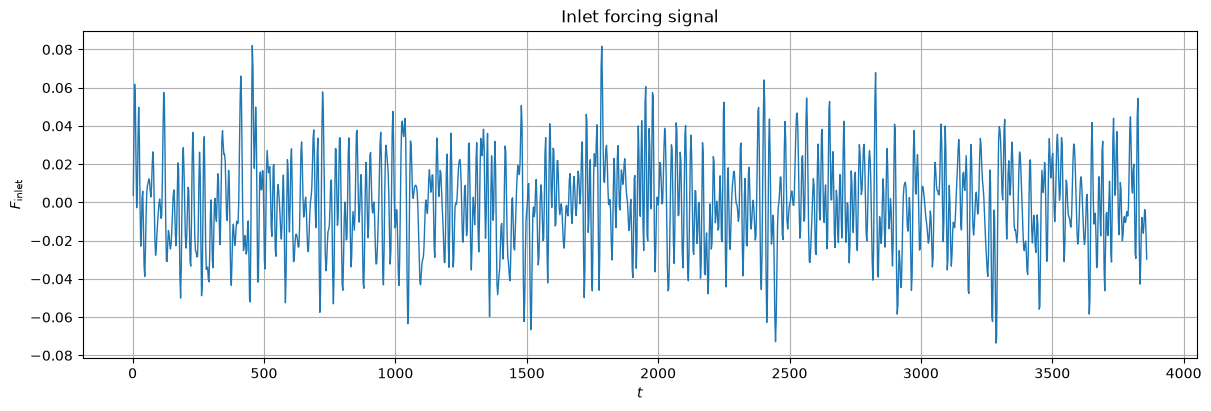

In [17]:
fig, ax = plt.subplots(
    figsize=(12, 4),
    constrained_layout=True,
)

ax.plot(
    time,
    F_inlet,
    linewidth=1.0,
)

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$F_{\mathrm{inlet}}$")
ax.set_title("Inlet forcing signal")
ax.grid(True)

plt.show()